In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print("Versión de TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


Versión de TensorFlow: 2.10.1
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [19]:
import tensorflow_datasets as tfds


(dataset, info) = tfds.load('tf_flowers', with_info=True, as_supervised=True)

print("Número de clases:", info.features['label'].num_classes)
print("Nombres de las clases:", info.features['label'].names)
print("Total de imágenes:", info.splits['train'].num_examples)

Número de clases: 5
Nombres de las clases: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Total de imágenes: 3670


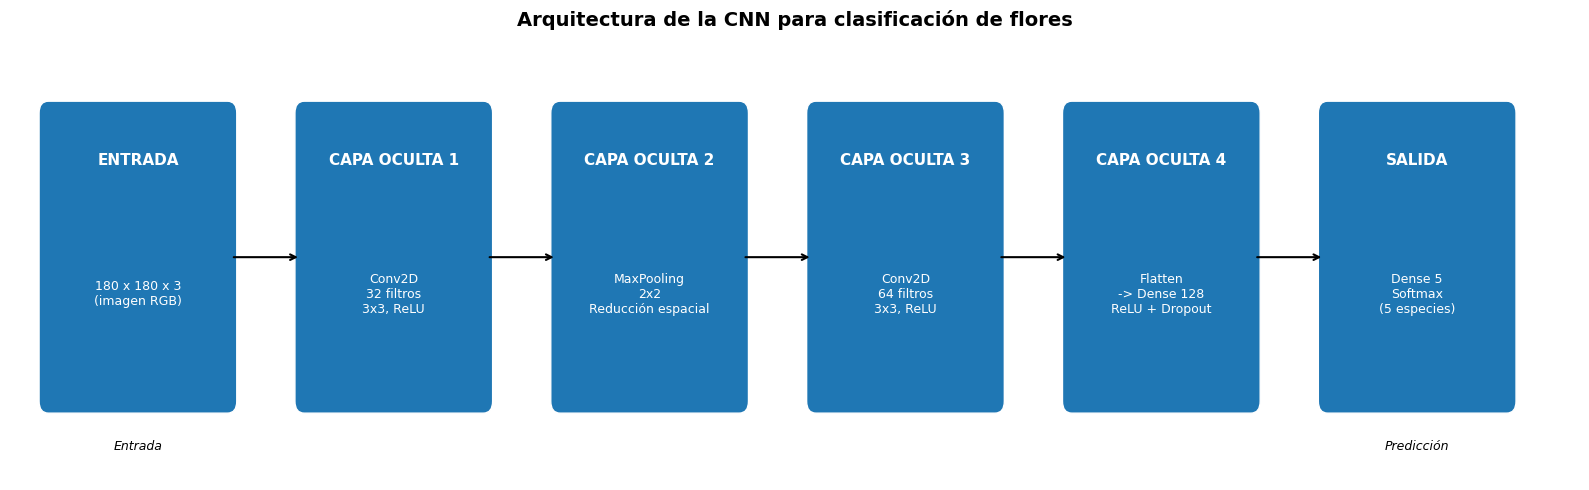

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Definimos las capas: (nombre, detalle, color)
capas = [
    ("ENTRADA", "180 x 180 x 3\n(imagen RGB)", "#1f77b4"),
    ("CAPA OCULTA 1", "Conv2D\n32 filtros\n3x3, ReLU", "#1f77b4"),
    ("CAPA OCULTA 2", "MaxPooling\n2x2\nReducción espacial", "#1f77b4"),
    ("CAPA OCULTA 3", "Conv2D\n64 filtros\n3x3, ReLU", "#1f77b4"),
    ("CAPA OCULTA 4", "Flatten\n-> Dense 128\nReLU + Dropout", "#1f77b4"),
    ("SALIDA", "Dense 5\nSoftmax\n(5 especies)", "#1f77b4"),
]

fig, ax = plt.subplots(figsize=(16, 5))

box_w, box_h = 1.6, 2.0
gap = 0.6
x = 0
centros_x = []

for nombre, detalle, color in capas:
    rect = patches.FancyBboxPatch(
        (x, 0), box_w, box_h,
        boxstyle="round,pad=0.05,rounding_size=0.08",
        linewidth=1, edgecolor="white", facecolor=color
    )
    ax.add_patch(rect)

    cx = x + box_w / 2
    centros_x.append(cx)

    ax.text(cx, box_h - 0.35, nombre, ha="center", va="center",
             fontsize=11, fontweight="bold", color="white")
    ax.text(cx, box_h / 2 - 0.25, detalle, ha="center", va="center",
             fontsize=9, color="white")

    x += box_w + gap

# Flechas entre cajas
for i in range(len(capas) - 1):
    x_inicio = centros_x[i] + box_w / 2
    x_fin = centros_x[i + 1] - box_w / 2
    ax.annotate("", xy=(x_fin, box_h / 2), xytext=(x_inicio, box_h / 2),
                 arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

ax.set_xlim(-0.3, x)
ax.set_ylim(-0.5, box_h + 0.5)
ax.axis("off")
ax.set_title("Arquitectura de la CNN para clasificación de flores", fontsize=14, fontweight="bold")

ax.text(centros_x[0], -0.3, "Entrada", ha="center", fontsize=9, style="italic")
ax.text(centros_x[-1], -0.3, "Predicción", ha="center", fontsize=9, style="italic")

plt.tight_layout()
plt.show()

In [21]:
import pathlib

# Descargamos el dataset de flores directamente (carpeta comprimida de imágenes)
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archivo_descargado = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
carpeta_datos = pathlib.Path(archivo_descargado)

# Contamos cuántas imágenes hay en total
total_imagenes = len(list(carpeta_datos.glob('*/*.jpg')))
print("Total de imágenes descargadas:", total_imagenes)

# Vemos qué carpetas (clases) hay
clases = [item.name for item in carpeta_datos.glob('*') if item.is_dir()]
print("Clases encontradas:", clases)


Total de imágenes descargadas: 3670
Clases encontradas: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


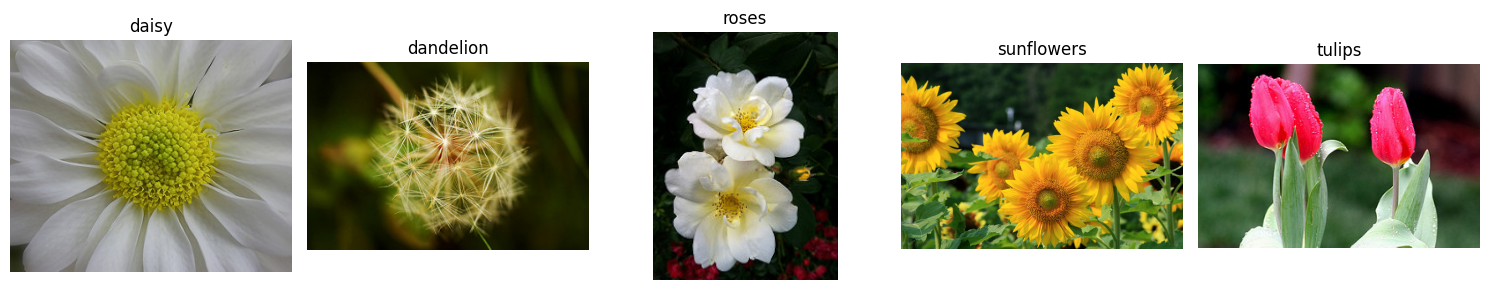

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Tomamos una imagen de ejemplo de cada clase
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, clase in zip(axes, clases):
    carpeta_clase = carpeta_datos / clase
    primera_imagen = list(carpeta_clase.glob('*.jpg'))[0]
    img = mpimg.imread(primera_imagen)
    ax.imshow(img)
    ax.set_title(clase)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [25]:
img_alto, img_ancho = 180, 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    carpeta_datos,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_alto, img_ancho),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    carpeta_datos,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_alto, img_ancho),
    batch_size=batch_size
)

nombres_clases = train_ds.class_names
print("Clases:", nombres_clases)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [26]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_alto, img_ancho, 3)),  # Normaliza los píxeles

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(nombres_clases), activation='softmax')  # 5 clases
])

modelo.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 89, 89, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 118336)           

In [27]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historial = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 [==============================] - 3s 31ms/step - loss: 1.6794 - accuracy: 0.3927 - val_loss: 1.1041 - val_accuracy: 0.5572
Epoch 2/10
92/92 [==============================] - 3s 28ms/step - loss: 0.9870 - accuracy: 0.6080 - val_loss: 1.0165 - val_accuracy: 0.6172
Epoch 3/10
92/92 [==============================] - 3s 28ms/step - loss: 0.6438 - accuracy: 0.7633 - val_loss: 0.9718 - val_accuracy: 0.6444
Epoch 4/10
92/92 [==============================] - 3s 28ms/step - loss: 0.3561 - accuracy: 0.8764 - val_loss: 1.2913 - val_accuracy: 0.6035
Epoch 5/10
92/92 [==============================] - 3s 28ms/step - loss: 0.1561 - accuracy: 0.9513 - val_loss: 1.3226 - val_accuracy: 0.6199
Epoch 6/10
92/92 [==============================] - 3s 28ms/step - loss: 0.0818 - accuracy: 0.9779 - val_loss: 1.9202 - val_accuracy: 0.6131
Epoch 7/10
92/92 [==============================] - 3s 28ms/step - loss: 0.0615 - accuracy: 0.9850 - val_loss: 1.8383 - val_accuracy: 0.6035
Epoch 8/10
92

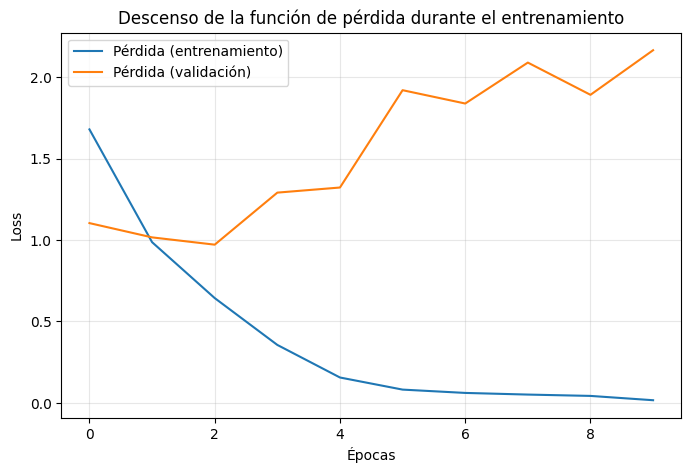

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(historial.history['loss'], label='Pérdida (entrenamiento)')
plt.plot(historial.history['val_loss'], label='Pérdida (validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Descenso de la función de pérdida durante el entrenamiento')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [29]:
import numpy as np

# Obtenemos las imágenes y etiquetas reales del set de validación
y_verdadero = []
y_predicho = []

for imagenes, etiquetas in val_ds:
    predicciones = modelo.predict(imagenes, verbose=0)
    y_predicho.extend(np.argmax(predicciones, axis=1))
    y_verdadero.extend(etiquetas.numpy())

y_verdadero = np.array(y_verdadero)
y_predicho = np.array(y_predicho)

print("Total de predicciones evaluadas:", len(y_verdadero))

Total de predicciones evaluadas: 734


In [30]:
import numpy as np

y_verdadero = []
y_predicho = []

for imagenes, etiquetas in val_ds:
    predicciones = modelo.predict(imagenes, verbose=0)
    y_predicho.extend(np.argmax(predicciones, axis=1))
    y_verdadero.extend(etiquetas.numpy())

y_verdadero = np.array(y_verdadero)
y_predicho = np.array(y_predicho)

print("Total de predicciones evaluadas:", len(y_verdadero))

Total de predicciones evaluadas: 734


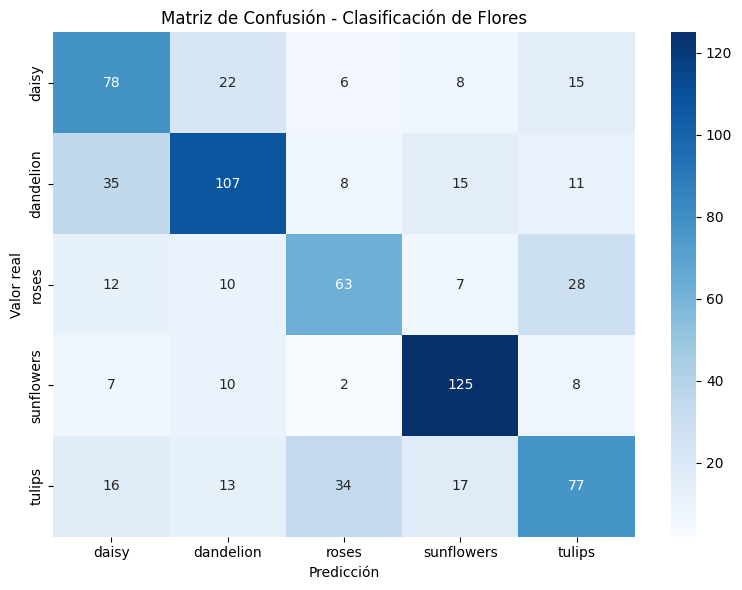

Accuracy general: 0.6131

Reporte completo por clase:

              precision    recall  f1-score   support

       daisy       0.53      0.60      0.56       129
   dandelion       0.66      0.61      0.63       176
       roses       0.56      0.53      0.54       120
  sunflowers       0.73      0.82      0.77       152
      tulips       0.55      0.49      0.52       157

    accuracy                           0.61       734
   macro avg       0.61      0.61      0.61       734
weighted avg       0.61      0.61      0.61       734



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusión
matriz = confusion_matrix(y_verdadero, y_predicho)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Clasificación de Flores')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas: Accuracy, Precision, Recall, F1-Score
print("Accuracy general:", round(accuracy_score(y_verdadero, y_predicho), 4))
print("\nReporte completo por clase:\n")
print(classification_report(y_verdadero, y_predicho, target_names=nombres_clases))

In [ ]:
modelo_v2 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(img_alto, img_ancho, 3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # <-- NUEVO: apaga aleatoriamente el 50% de las neuronas durante el entrenamiento
    tf.keras.layers.Dense(len(nombres_clases), activation='softmax')
])

modelo_v2.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    15,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,167,173 (57.86 MB)

 Trainable params: 15,167,173 (57.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.4063 - loss: 1.6542 - val_accuracy: 0.5504 - val_loss: 1.1858
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5749 - loss: 1.0844 - val_accuracy: 0.6376 - val_loss: 1.0174
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.6958 - loss: 0.8462 - val_accuracy: 0.6499 - val_loss: 0.9326
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.7933 - loss: 0.6042 - val_accuracy: 0.6308 - val_loss: 0.9761
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.8621 - loss: 0.4024 - val_accuracy: 0.6308 - val_loss: 1.1417
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9094 - loss: 0.2814 - val_accuracy: 0.6172 - val_loss: 1.1476
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9356 - loss: 0.1932 - val_accuracy: 0.6376 - val_loss: 1.3690
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9516 - loss: 0.1675 - val_accuracy: 0.6267 -

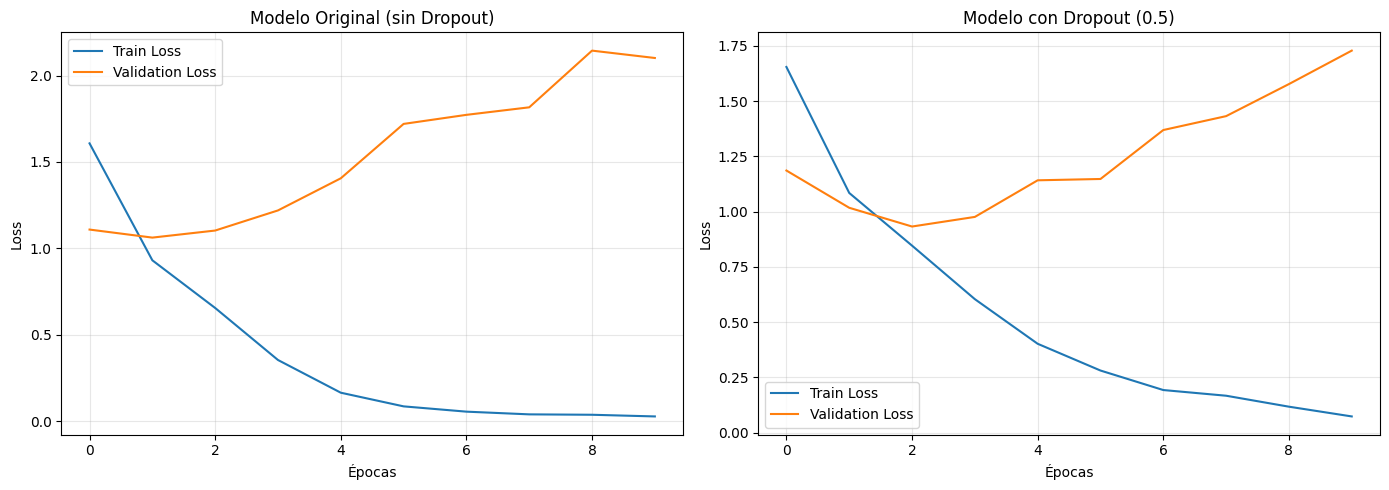

In [ ]:
import matplotlib.pyplot as plt

# Compile and train modelo_v2 to get historial_v2
modelo_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historial_v2 = modelo_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # You can adjust the number of epochs if needed
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Modelo original (sin Dropout)
axes[0].plot(historial.history['loss'], label='Train Loss')
axes[0].plot(historial.history['val_loss'], label='Validation Loss')
axes[0].set_title('Modelo Original (sin Dropout)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Modelo con Dropout
axes[1].plot(historial_v2.history['loss'], label='Train Loss')
axes[1].plot(historial_v2.history['val_loss'], label='Validation Loss')
axes[1].set_title('Modelo con Dropout (0.5)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparativa_loss.png', dpi=150, bbox_inches='tight')
plt.show()